# 1. Importing necessary libraries and dataset with engineered features

In [23]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from tensorflow.keras import losses

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [24]:
#Importing the Dataframe with the features

df = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/CA01-MachineLearning/Python-Forecasting-Electrical-Demand-on-Spain/part_2_output_features_engineered.csv',
                parse_dates = ['timestamp'])

In [25]:
#Setting the timestamp as the index

df.set_index('timestamp', inplace = True)

The method of Unobserved Components was performed by (TOTH, 2021) achieving consistent results in a dataset with similar properties of the one treated in this project, and therefore, we will use the same method to analyse how well it performs in our case. The model will be applied as it follows. All the parameters used to create the model were presented by (TOTH, 2021), however, the values chosen for each one of them were found by multiple attempts, observing and trying to increase the value of R squared.

# 2. Training the model

In [26]:
#Creating dummies of the year in the dataset

dummies = pd.get_dummies(df['year'], prefix='year')

# Join back to original DataFrame (drop the original if you like)
df = pd.concat([df.drop('year', axis=1), dummies], axis=1)

In [27]:
#Creating dummies of the season in the dataset

dummies = pd.get_dummies(df['season'], prefix='season')

# Join back to original DataFrame (drop the original if you like)
df = pd.concat([df.drop('season', axis=1), dummies], axis=1)

In [28]:
#Defining the train and test dataset

df_train_validation = df.loc['2015-01-01 00:00:00':'2017-12-31 23:00:00']
df_test = df.loc['2018-01-01 00:00:00':'2018-04-01 00:00:00']

In [29]:
#Defining the train exogenous variables for the Unobserved components method

df_UC_train_exog = df.loc['2015-01-01 00:00:00':'2017-12-31 23:00:00'][['year_2015',
                                                                        'year_2016',
                                                                        'year_2017',
                                                                        'year_2018',
                                                                        'is_holiday',
                                                                        'is_weekend',
                                                                        'is_end_of_year',
                                                                        'is_christmas']].astype('float64')

In [30]:
#Defining the test exogenous variables for the Unobserved components method

df_UC_test_exog = df.loc['2018-01-01 00:00:00':'2018-04-01 00:00:00'][['year_2015',
                                                                        'year_2016',
                                                                        'year_2017',
                                                                        'year_2018',
                                                                        'is_holiday',
                                                                        'is_weekend',
                                                                        'is_end_of_year',
                                                                        'is_christmas']].astype('float64')

In [31]:
#Unobserved Components model definition
UC_model = sm.tsa.UnobservedComponents(df_train_validation['total load actual'],
                                       trend=True,
                                       level=True,
                                       irregular=True,
                                       exog = df_UC_train_exog,
                                       stochastic_level = False,
                                       stochastic_trend = False,
                                       stochastic_freq_seasonal = [False, False,False],
                                       freq_seasonal=[{'period': 24, 'harmonics': 12},
                                                       {'period': 168, 'harmonics': 1},
                                                       {'period': 8760, 'harmonics': 8}]
                                      )

In [32]:
#Fitting model to train data

UC_model_fit = UC_model.fit()

In [33]:
#printing statsmodels summary for model
print(UC_model_fit.summary())

                           Unobserved Components Results                            
Dep. Variable:            total load actual   No. Observations:                26304
Model:                  deterministic trend   Log Likelihood             -245432.087
                    + freq_seasonal(24(12))   AIC                         490882.174
                    + freq_seasonal(168(1))   BIC                         490955.756
                   + freq_seasonal(8760(8))   HQIC                        490905.934
Date:                      Thu, 02 Apr 2026                                         
Time:                              20:24:59                                         
Sample:                          01-01-2015                                         
                               - 12-31-2017                                         
Covariance Type:                        opg                                         
                          coef    std err          z      P>|z|  

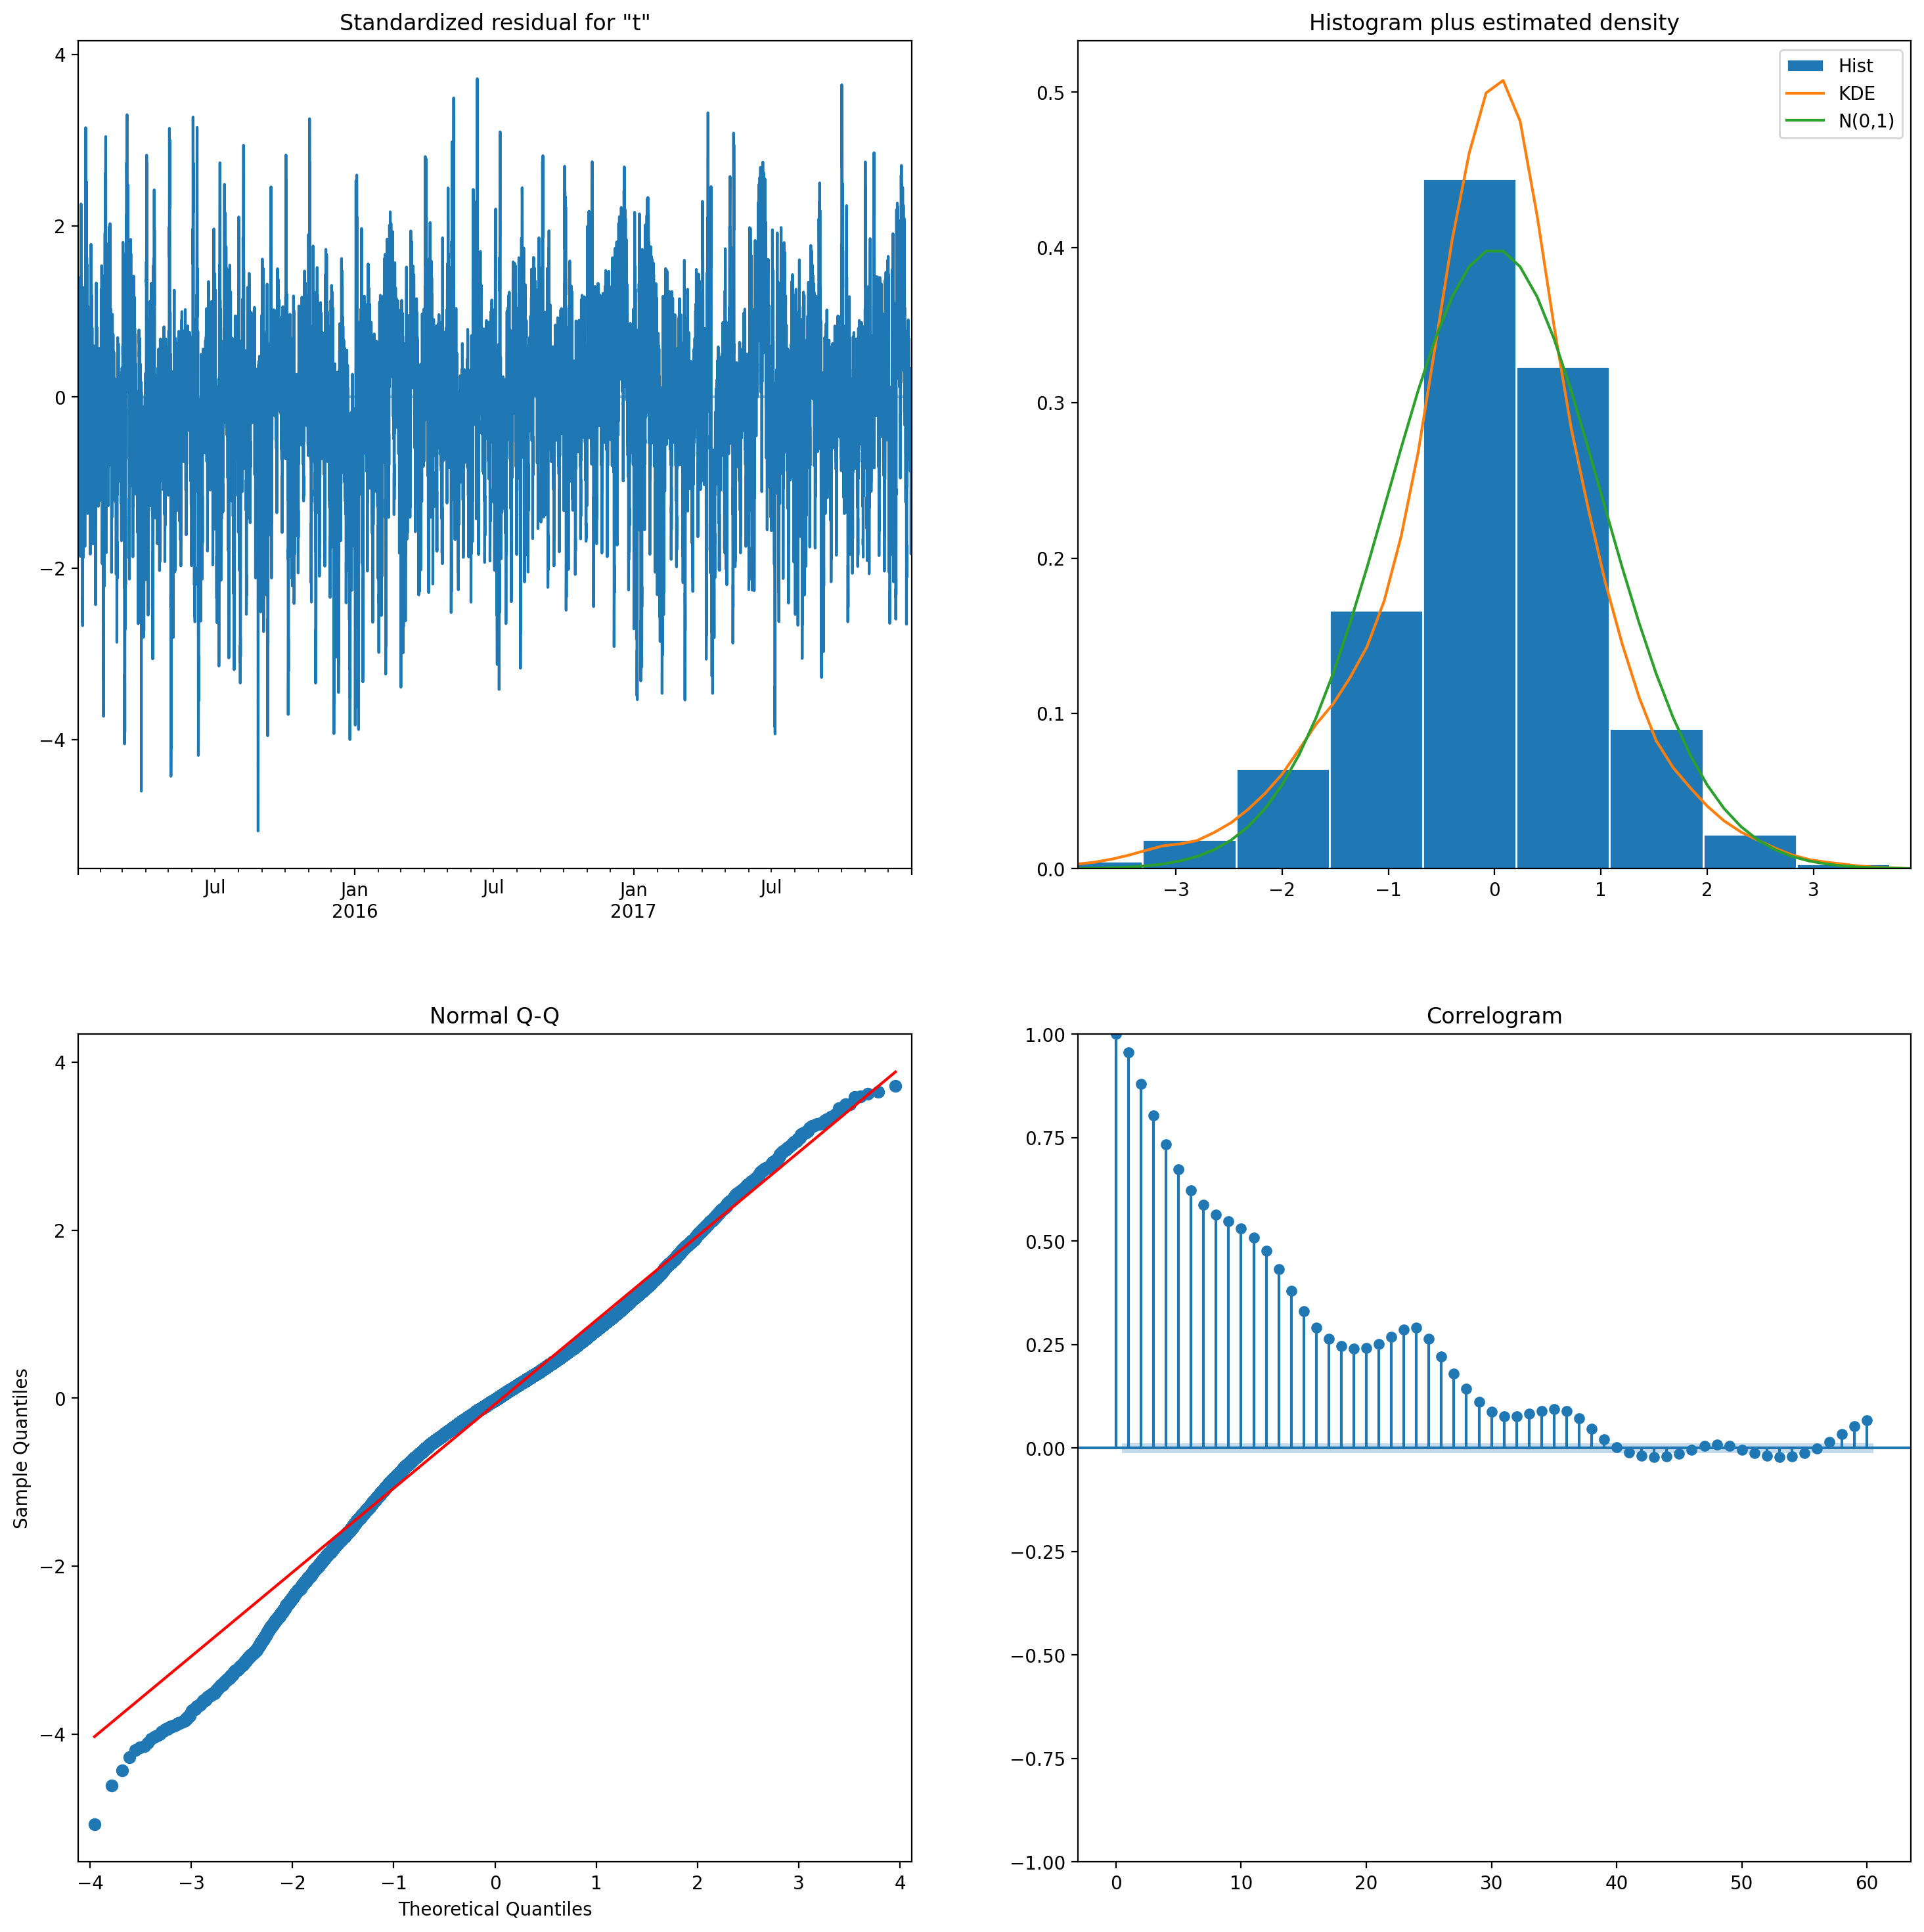

In [34]:
#plotting residual diagnostics of Unobserved Components model
UC_model_fit.plot_diagnostics(figsize=(18,18),lags=60).set_dpi(200)
plt.savefig('UCDiagnosis.png');

In [35]:
#Forecasting with the fitted model

UC_test_pred = UC_model_fit.predict(start=df_test.index[0],
                                end = df_test.index[-1],
                                exog = df_UC_test_exog)

In [36]:
UC_mape = losses.mape(df_test['total load actual'], UC_test_pred )
print(UC_mape)

tf.Tensor(7.955591462994809, shape=(), dtype=float64)


In [37]:
df_test['UC_pred'] = UC_test_pred.values

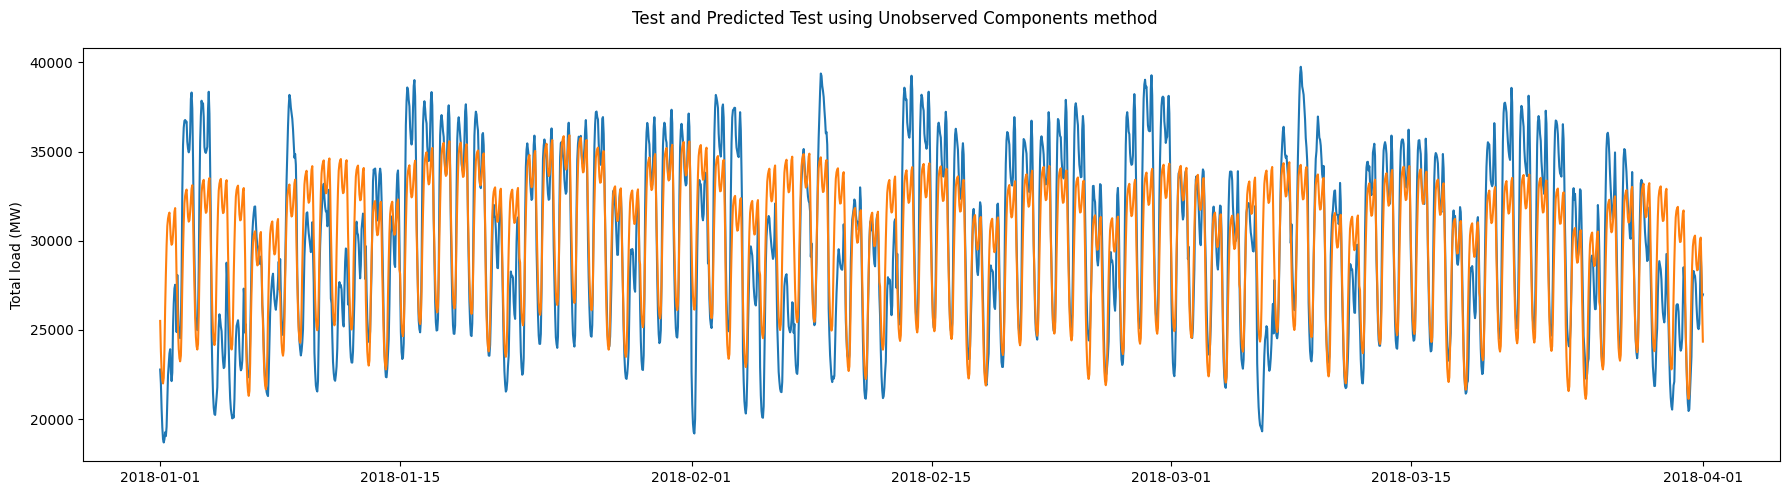

In [38]:
#Plotting predicted data against the original data.

fig, ax = plt.subplots(figsize = [18,5])

ax.plot(df_test.index, df_test['total load actual'], label = 'Actual')
ax.plot(df_test.index, df_test['UC_pred'], label = 'Prediction')
ax.set_ylabel('Total load (MW)')

# Display the title of the figure
fig.suptitle('Test and Predicted Test using Unobserved Components method')
fig.tight_layout()
fig.show()

The model seem to behave similar to the expected, however, it does not captures effectively irregularities on data. The shape of the graph looks similar to a deterministic harmonic series with the specified seasonalities. 

Tweeking the harmonics of the models has changed its performance significantly, but it was still insufficient to the model to outperform the baselines. The model captures well the seasonalities, however if fails to identify the the higher peaks of the data of the deeper troughs.

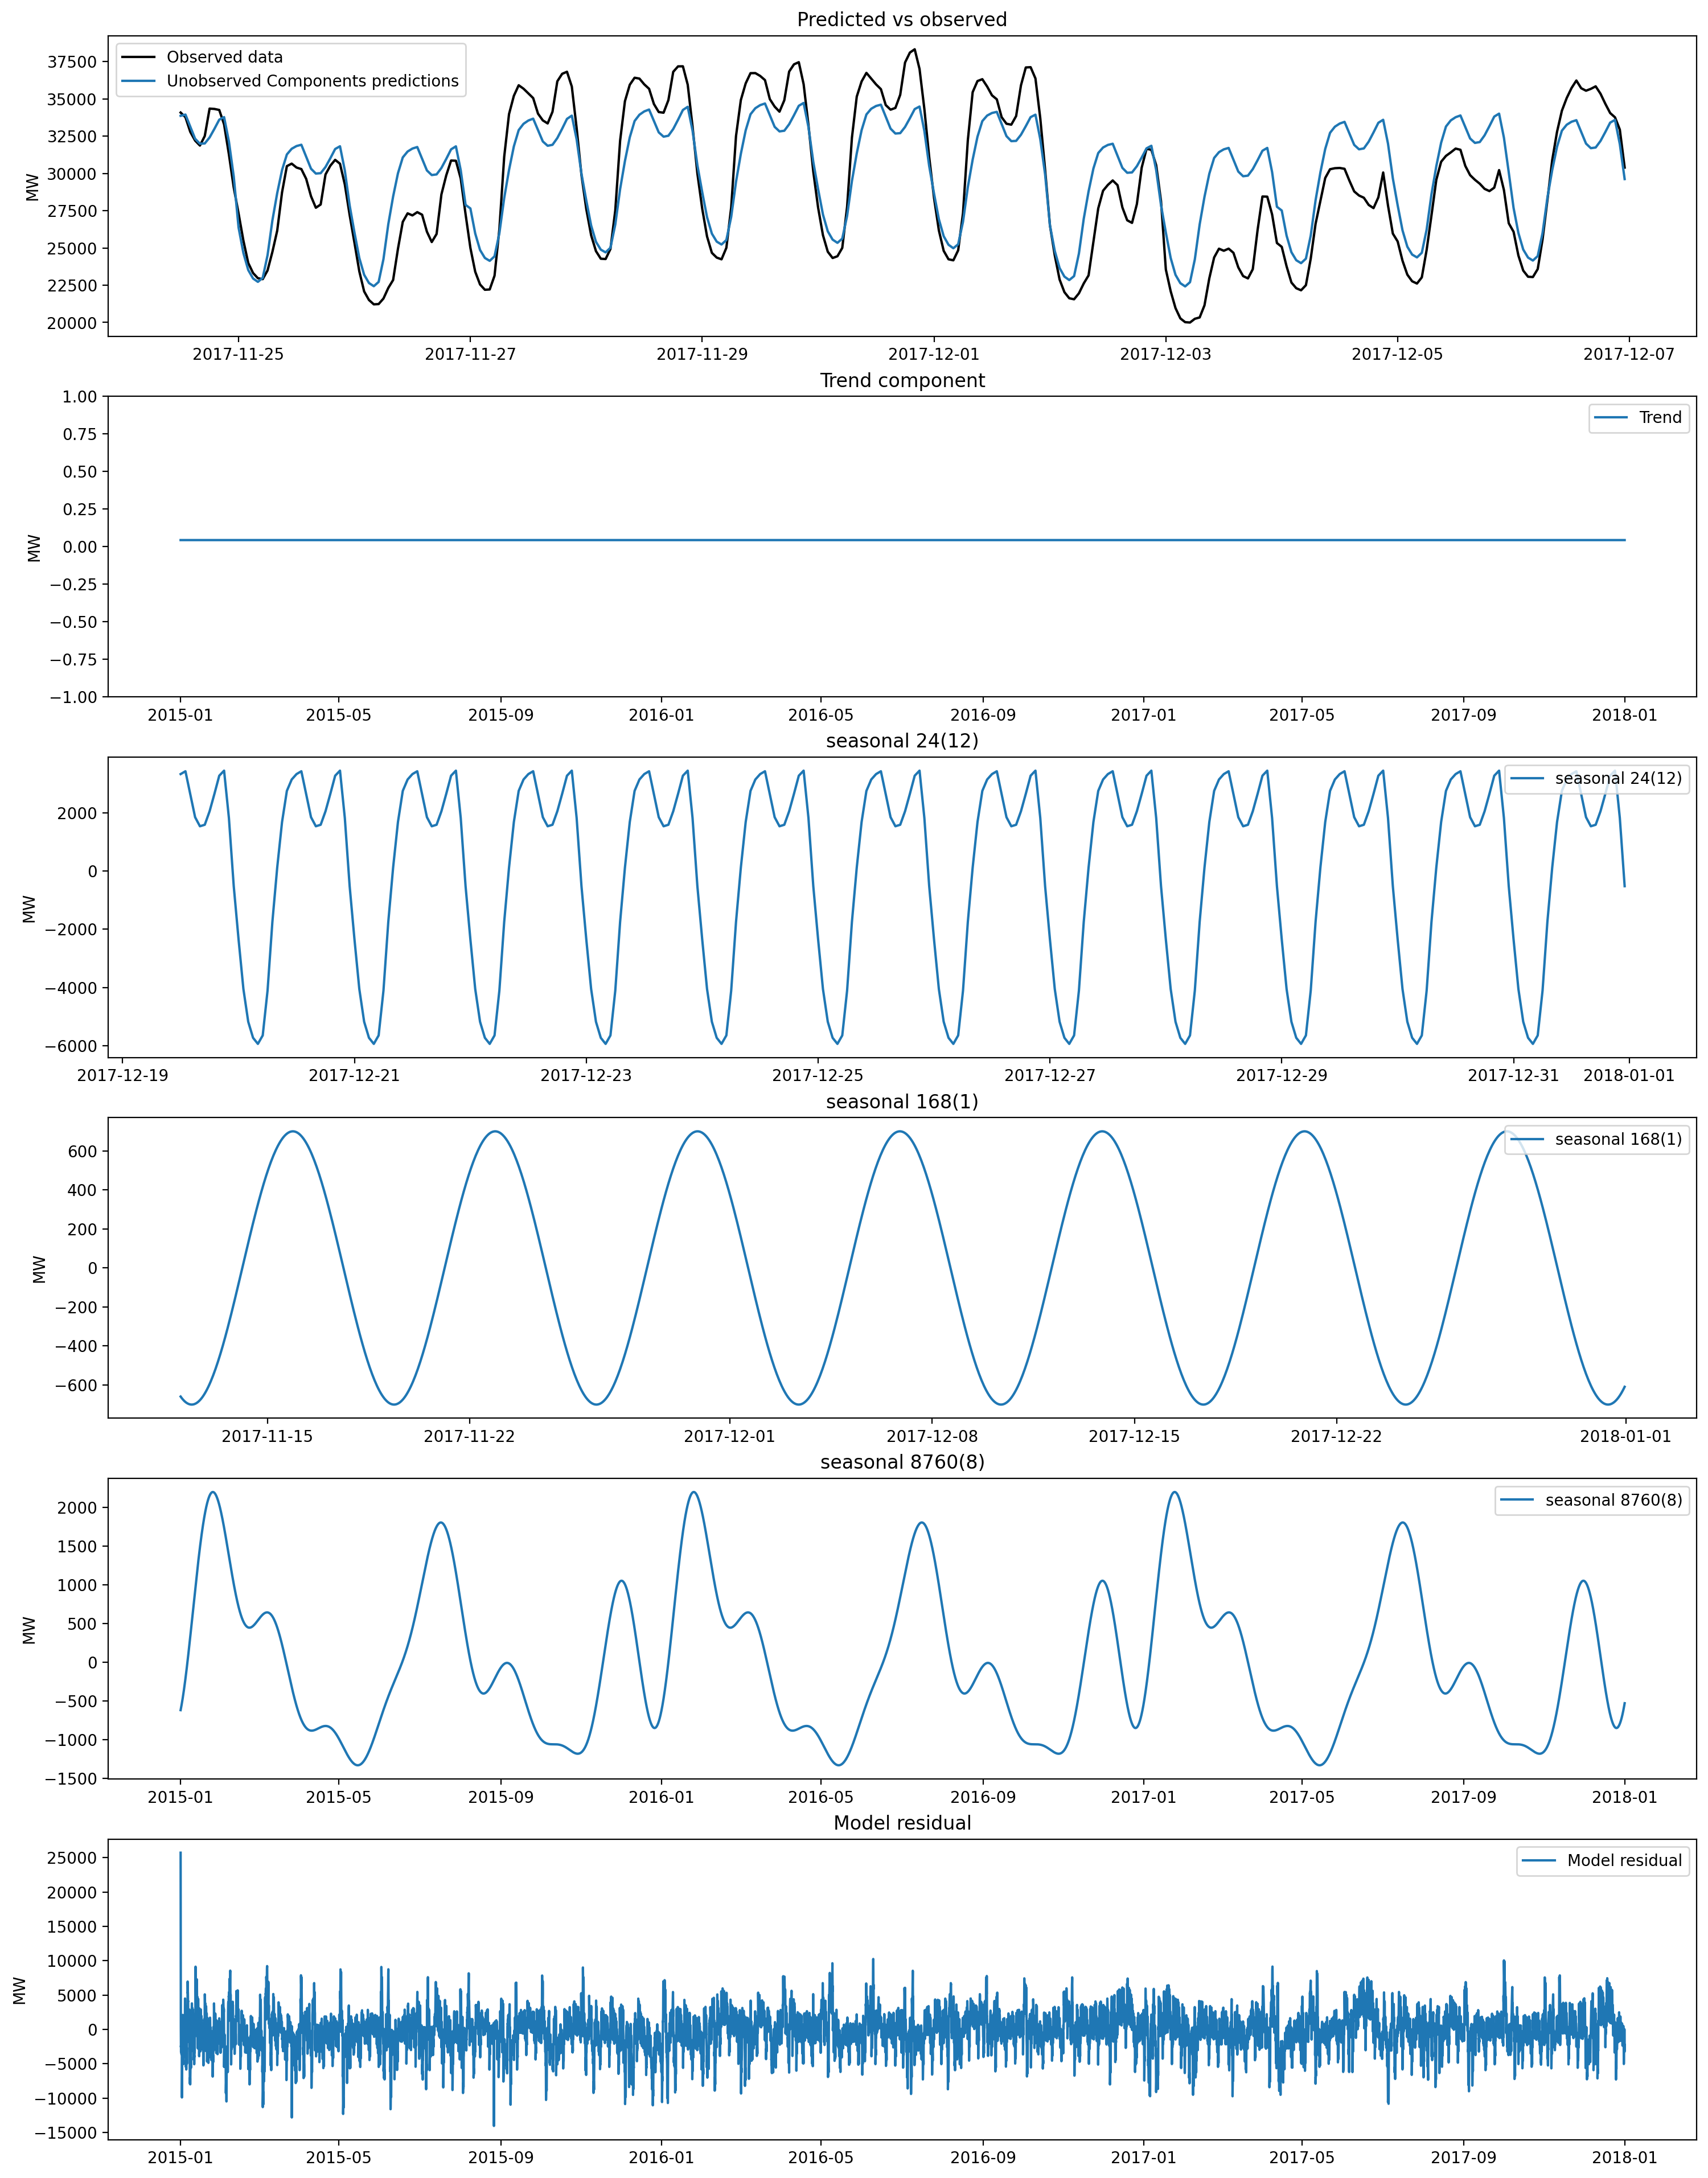

In [39]:
fig, ax = plt.subplots(6,1,figsize=(18,24),dpi=200)

#custom plotting of observed train data in style of results class '.plot_components()' method

#plotting observed data vs. in-sample prediction in arbitrary timestamps
ax[0].plot(df_train_validation.index[-900:-600],
           df_train_validation['total load actual'][-900:-600], 
           label='Observed data', color='black');
ax[0].plot(df_train_validation.index[-900:-600],
           UC_model_fit.fittedvalues[-900:-600],
           label='Unobserved Components predictions');
ax[0].legend()

#plotting smoothed level component
#axes[1].plot(training.index, model_UC1res.level['smoothed'], label='Level');
#axes[1].legend();

#plotting smoothed trend component
ax[1].plot(df_train_validation.index, UC_model_fit.trend['smoothed'], label='Trend');
ax[1].set_ylim(-1,1)
ax[1].legend();

limits = [-300, -1200, 0]

#plotting smoothed seasonal components with arbitrary time window scales
for i in range(2,5,1):
    ax[i].plot(df_train_validation.index[limits[i-2]:], 
               UC_model_fit.freq_seasonal[i-2]['smoothed'][limits[i-2]:], 
               label=UC_model_fit.freq_seasonal[i-2]['pretty_name']);
    ax[i].legend(loc='upper right');

#plotting residuals
ax[5].plot(df_train_validation.index, UC_model_fit.resid, label='Model residual');
ax[5].legend();

#list of subplot titles
axtitles = ['Predicted vs observed',
            'Trend component',
            UC_model_fit.freq_seasonal[0]['pretty_name'],
            UC_model_fit.freq_seasonal[1]['pretty_name'],
            UC_model_fit.freq_seasonal[2]['pretty_name'],
            'Model residual']

#setting y labels and subplot titles (former is missing from '.plot_components()')
for i,a in enumerate(ax):
    a.set_ylabel('MW')
    a.set_title(axtitles[i])

plt.show();